In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes 
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split

In [2]:
data=load_diabetes(as_frame=True,scaled=False)

In [3]:
x=data.data
y=data.target
df=pd.concat([x,y],axis=1)

In [4]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


In [16]:
x=df[['bmi']]
train_err=[]
test_err=[]
degrees=[1,2,3,4,5,10]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
le=LinearRegression()

In [17]:
for degree in degrees:
    p=PolynomialFeatures(degree=degree)
    x_train_poly=p.fit_transform(x_train)
    x_test_poly=p.transform(x_test)

    le.fit(x_train_poly,y_train)

    train_pred=le.predict(x_train_poly)
    test_pred=le.predict(x_test_poly)
    
    train_mse=mean_squared_error(y_train,train_pred)
    test_mse=mean_squared_error(y_test,test_pred)
    
    train_err.append(train_mse)
    test_err.append(test_mse)

    print('degree = ',degree,
         'train_err = ',train_mse,
         'test_err= ',test_mse)
    
    

degree =  1 train_err =  3854.11265207582 test_err=  4061.8259284949268
degree =  2 train_err =  3849.3331334111795 test_err=  4085.025480871634
degree =  3 train_err =  3848.447237857027 test_err=  4064.4433837168303
degree =  4 train_err =  3831.05720856141 test_err=  4226.14487708565
degree =  5 train_err =  3823.763813306919 test_err=  4085.8455512073747
degree =  10 train_err =  3809.3208760210055 test_err=  4236.324304604869


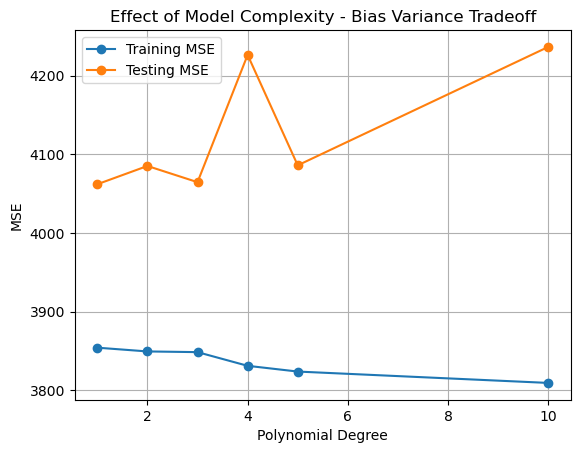

In [19]:

plt.plot(degrees, train_err, marker='o', label="Training MSE")
plt.plot(degrees, test_err, marker='o', label="Testing MSE")

plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Effect of Model Complexity - Bias Variance Tradeoff")
plt.legend()
plt.grid()
plt.show()
